In [1]:
import pandas as pd

In [3]:
data = pd.read_csv("amzn.csv", index_col = ["Date"])
data.head()

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
1997-05-16,22.38,23.75,20.50,20.75,1225000.0,0.0,1.0,1.865000,1.979167,1.708333,1.729167,14700000.0
1997-05-19,20.50,21.25,19.50,20.50,508900.0,0.0,1.0,1.708333,1.770833,1.625000,1.708333,6106800.0
1997-05-20,20.75,21.00,19.63,19.63,455600.0,0.0,1.0,1.729167,1.750000,1.635833,1.635833,5467200.0
1997-05-21,19.25,19.75,16.50,17.13,1571100.0,0.0,1.0,1.604167,1.645833,1.375000,1.427500,18853200.0
1997-05-22,17.25,17.38,15.75,16.75,981400.0,0.0,1.0,1.437500,1.448333,1.312500,1.395833,11776800.0


In [4]:
data = data[["Close"]]
data.head()

,Close
Date,
1997-05-16,20.75
1997-05-19,20.50
1997-05-20,19.63
1997-05-21,17.13
1997-05-22,16.75


In [5]:
data.columns = data.columns.str.replace("Close", "Value")

data.head()

,Value
Date,
1997-05-16,20.75
1997-05-19,20.50
1997-05-20,19.63
1997-05-21,17.13
1997-05-22,16.75


In [6]:
data.tail()

,Value
Date,
2018-03-21,1581.86
2018-03-22,1544.10
2018-03-23,1495.56
2018-03-26,1555.86
2018-03-27,1497.05


<Axes: xlabel='Date'>

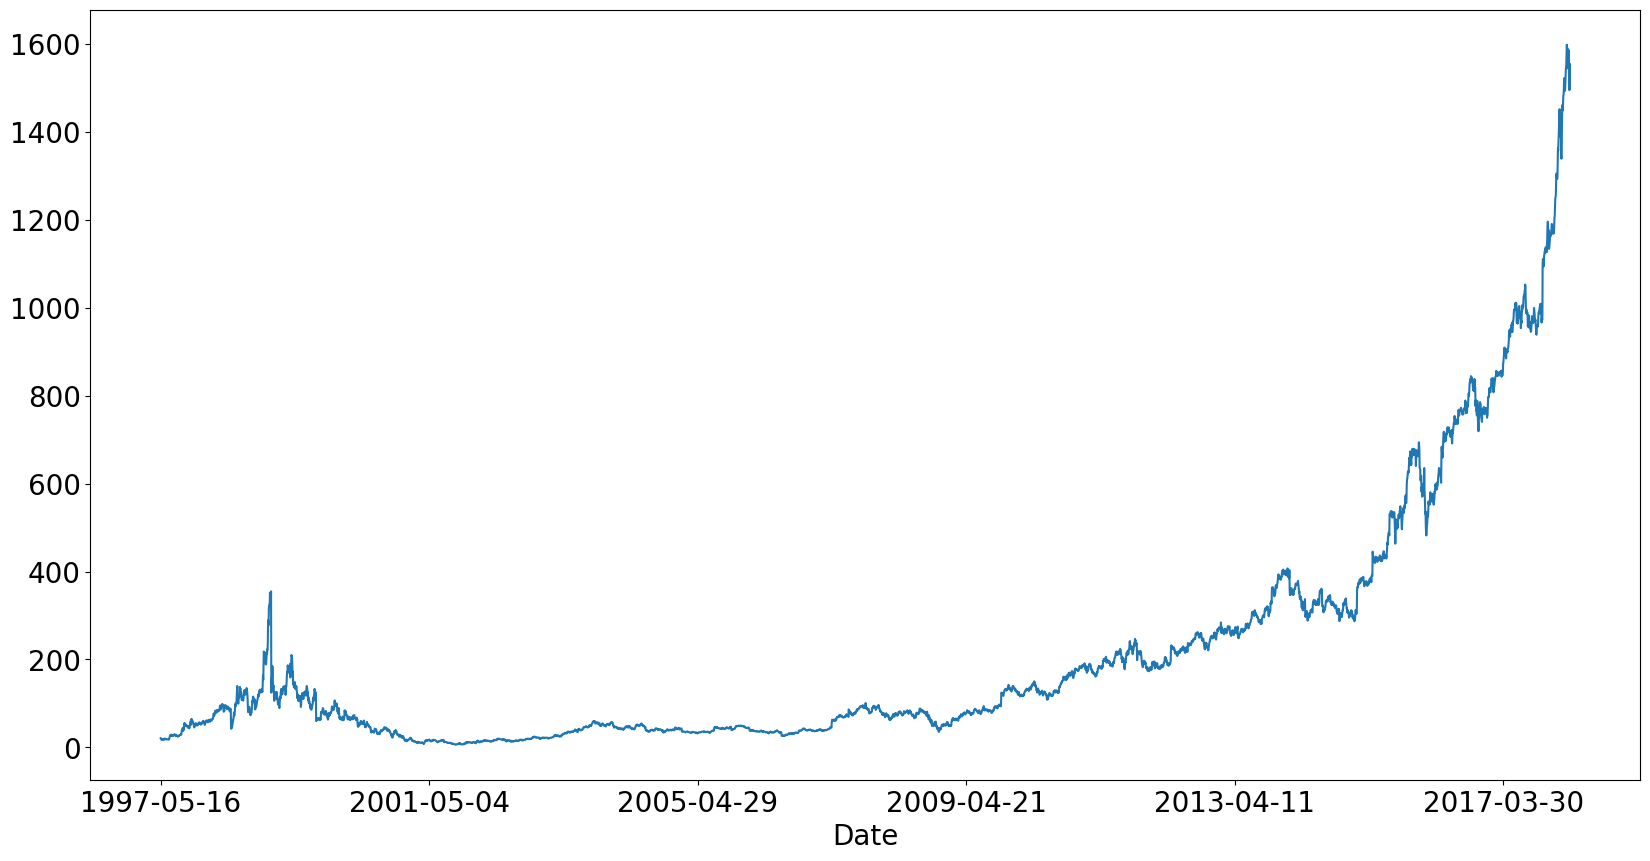

In [10]:
import matplotlib.pyplot as pyplot
pyplot.rcParams.update({"font.size" : 20})
data["Value"].plot(figsize= (20,10))

In [11]:
forecast = 30
data["Prediction"] = data[["Value"]].shift(-forecast)
data.head()

,Value,Prediction
Date,,
1997-05-16,20.75,18.50
1997-05-19,20.50,18.19
1997-05-20,19.63,19.06
1997-05-21,17.13,22.94
1997-05-22,16.75,24.00


In [24]:
import numpy

X = numpy.array(data.drop(['Prediction'], axis = 1))

print(X)


[[  20.75]
 [  20.5 ]
 [  19.63]
 ...
 [1495.56]
 [1555.86]
 [1497.05]]


In [25]:
from sklearn import preprocessing

X = preprocessing.scale(X)

print(X)

[[-0.67708476]
 [-0.67798312]
 [-0.6811094 ]
 ...
 [ 4.62253907]
 [ 4.83922279]
 [ 4.62789328]]


In [26]:
X_forecast = X[-forecast:]

X = X[:-forecast]

print(X_forecast)

[[4.33129172]
 [4.46259558]
 [4.5010812 ]
 [4.45411509]
 [4.52476189]
 [4.57711814]
 [4.58373005]
 [4.63849389]
 [4.71736964]
 [4.68154316]
 [4.68323207]
 [4.61495694]
 [4.63939225]
 [4.72333473]
 [4.77375053]
 [4.80019816]
 [4.82484908]
 [4.92197944]
 [4.99205129]
 [4.95536239]
 [4.96549586]
 [4.9343049 ]
 [4.89607083]
 [4.79994662]
 [4.94936137]
 [4.93265193]
 [4.79696408]
 [4.62253907]
 [4.83922279]
 [4.62789328]]


In [28]:
y = numpy.array(data["Prediction"])

print(y)

[18.5  18.19 19.06 ...   nan   nan   nan]


In [29]:
y = y[:-forecast]

print(y)

[  18.5    18.19   19.06 ... 1495.56 1555.86 1497.05]


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

print(X_train)

[[-0.43258791]
 [-0.40287026]
 [-0.48321931]
 ...
 [ 0.35268396]
 [-0.44372753]
 [-0.45425628]]


In [31]:
print(X_train.shape)

(4174, 1)


In [32]:
print(y_train.shape)

(4174,)


In [33]:
print(X_test.shape)

(1044, 1)


In [34]:
print(y_test.shape)

(1044,)


In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [37]:
confidence = model.score(X_test, y_test)

print(confidence)

0.9840392157791195


In [38]:
forecast_predicted = model.predict(X_forecast)

print(forecast_predicted)

[1500.60200629 1539.46173912 1550.85166081 1536.95191511 1557.86002532
 1573.35499815 1575.3118101  1591.51931771 1614.86280801 1604.25986504
 1604.75970287 1584.55349259 1591.7851889  1616.6281927  1631.54888376
 1639.37613154 1646.67163693 1675.41762977 1696.15558243 1685.29740311
 1688.29643011 1679.06538247 1667.74990471 1639.3016876  1683.52138358
 1678.57617948 1638.41899526 1586.79744541 1650.92557594 1588.38203769]


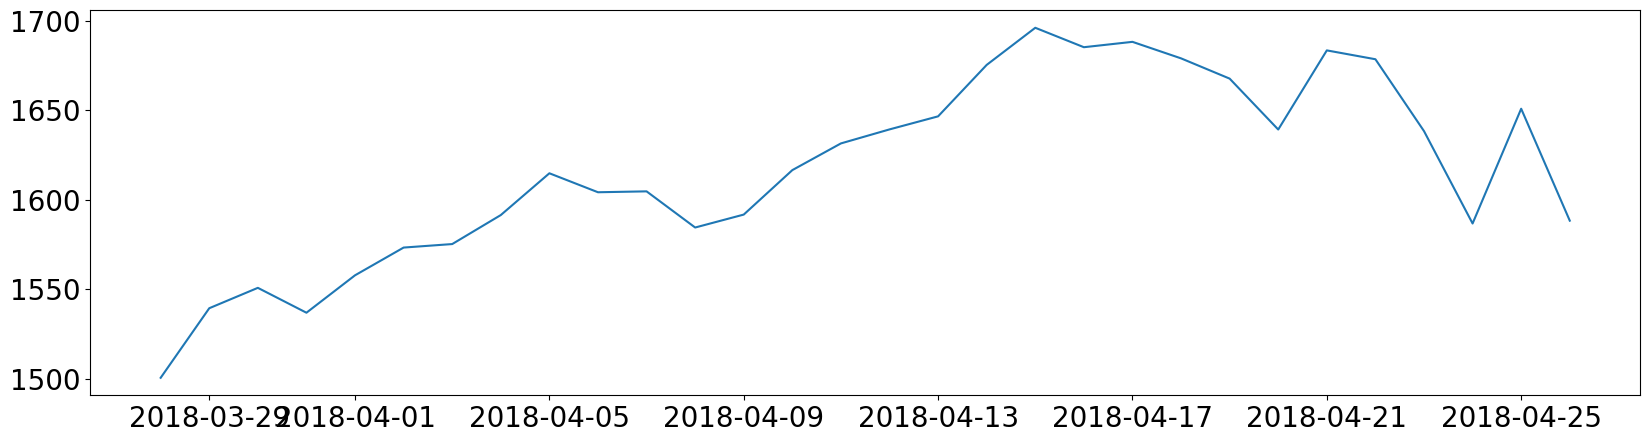

In [42]:
forecast_dates = pd.date_range(start = "2018-03-28", end = "2018-04-26")

pyplot.rcParams["figure.figsize"] = (20,5)

pyplot.plot(forecast_dates , forecast_predicted)